In [1]:
import os
import h5py
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["TeX Gyre Pagella", "Book Antiqua", "Palatino Linotype", "DejaVu Serif"]
})

### Load CNN+MLP globals predictions (validation split)

In [8]:
pred_dir = "/projects/mccleary_group/habjan.e/TNG/Data/conditional_diffusion_data/cnn_mlp_globals"
val_pred_path = os.path.join(pred_dir, "cnn_mlp_globals_predictions_val.h5")

with h5py.File(val_pred_path, "r") as f:
    pred_phys = f["predictions_physical"][:]
    targ_phys = f["targets_physical"][:]
    column_names = [c.decode("utf-8") for c in f["column_names"][:]]

print("columns:", column_names)
print("pred shape:", pred_phys.shape, "target shape:", targ_phys.shape)

# columns: [mass_log10_msun, axis_a_mpc, axis_b_mpc, axis_c_mpc]
true_masses = targ_phys[:, 0]
sample_masses = pred_phys[:, 0]
true_shapes = targ_phys[:, 1:4]
sample_shapes = pred_phys[:, 1:4]

columns: ['mass_log10_msun', 'axis_a_mpc', 'axis_b_mpc', 'axis_c_mpc']
pred shape: (1000, 4) target shape: (1000, 4)


### Cube mass: true vs predicted

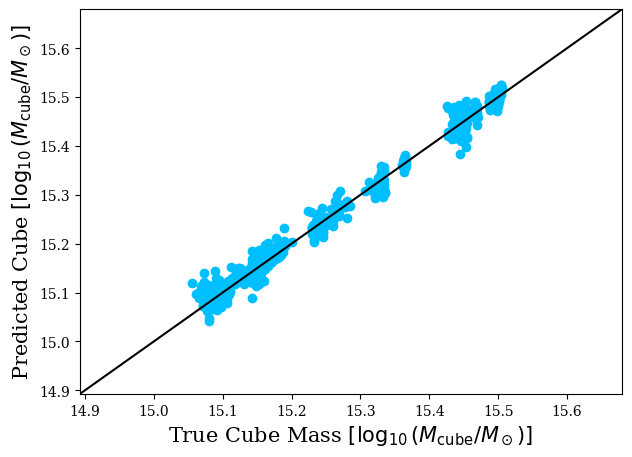

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(true_masses, sample_masses, c='deepskyblue')

concat_mass = np.concatenate([true_masses, sample_masses])
min_m, max_m = np.min(concat_mass) * 0.99, np.max(concat_mass) * 1.01

ax.set_xlim(min_m, max_m)
ax.set_ylim(min_m, max_m)

one_one = np.linspace(min_m * 0.1, max_m * 10, 25)
ax.plot(one_one, one_one, c='k')

ax.set_xlabel(r'True Cube Mass $[\log_{10}(M_{\rm cube}/M_\odot)]$', fontsize=15)
ax.set_ylabel(r'Predicted Cube $[\log_{10}(M_{\rm cube}/M_\odot)]$', fontsize=15)

fig.savefig("/home/habjan.e/TNG/cluster_deprojection/figures/cube_masses_cnn_mlp.png", bbox_inches="tight")
plt.show()

### Shape axis lengths: true vs predicted, colored by true cube mass

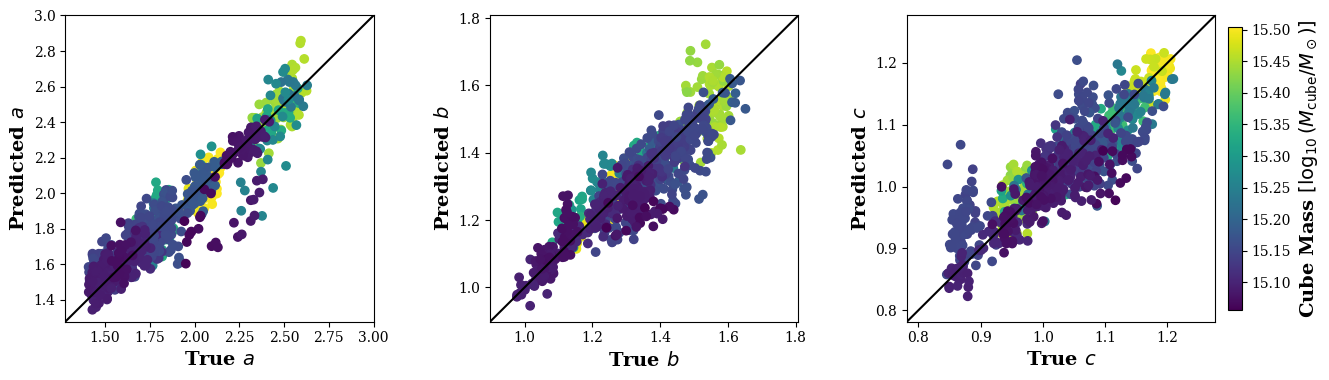

In [14]:
cmap = 'viridis'

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(13.5, 4), constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.2, h_pad=0.2, wspace=0.1, hspace=0.1)
ax1, ax2, ax3 = axes[0], axes[1], axes[2]

one_one = np.linspace(0, 10)

im1 = ax1.scatter(true_shapes[:, 0], sample_shapes[:, 0], c=true_masses, cmap=cmap)
ax1.plot(one_one, one_one, c='k')
ax1.set_xlabel(r"True $a$", fontsize=14, fontweight='semibold')
ax1.set_ylabel(r"Predicted $a$", fontsize=14, fontweight='semibold')

concat_shape = np.concatenate([true_shapes[:, 0], sample_shapes[:, 0]])
min_s, max_s = np.min(concat_shape) * 0.95, np.max(concat_shape) * 1.05
ax1.set_xlim(min_s, max_s)
ax1.set_ylim(min_s, max_s)

im2 = ax2.scatter(true_shapes[:, 1], sample_shapes[:, 1], c=true_masses, cmap=cmap)
ax2.plot(one_one, one_one, c='k')
ax2.set_xlabel(r"True $b$", fontsize=14, fontweight='semibold')
ax2.set_ylabel(r"Predicted $b$", fontsize=14, fontweight='semibold')

concat_shape = np.concatenate([true_shapes[:, 1], sample_shapes[:, 1]])
min_s, max_s = np.min(concat_shape) * 0.95, np.max(concat_shape) * 1.05
ax2.set_xlim(min_s, max_s)
ax2.set_ylim(min_s, max_s)

im3 = ax3.scatter(true_shapes[:, 2], sample_shapes[:, 2], c=true_masses, cmap=cmap)
ax3.plot(one_one, one_one, c='k')
ax3.set_xlabel(r"True $c$", fontsize=14, fontweight='semibold')
ax3.set_ylabel(r"Predicted $c$", fontsize=14, fontweight='semibold')

concat_shape = np.concatenate([true_shapes[:, 2], sample_shapes[:, 2]])
min_s, max_s = np.min(concat_shape) * 0.95, np.max(concat_shape) * 1.05
ax3.set_xlim(min_s, max_s)
ax3.set_ylim(min_s, max_s)

cbar = fig.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
cbar.set_label(r'Cube Mass $[\log_{10}(M_{\rm cube}/M_\odot)]$', fontsize=14, fontweight='semibold')

fig.savefig("/home/habjan.e/TNG/cluster_deprojection/figures/cube_shapes_cnn_mlp.png", bbox_inches="tight")
plt.show()

In [16]:
print(np.median(10**sample_masses / 10**true_masses))

print(np.median(abs(10**sample_masses - 10**true_masses) / 10**true_masses))

print(np.median(sample_shapes / true_shapes, axis = 0))

print(np.median(abs(sample_shapes - true_shapes), axis = 0))

1.0036937
0.018599648
[1.0027914  0.9957919  0.99850935]
[0.05415255 0.0316934  0.02066076]
